In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.chdir('/content/drive/MyDrive/NLP/Translation')
!ls

'arabic dataset'      get-pip.py.1		  'Translation v2.ipynb'
'chinese dataset'    'italian dataset'		  'Translation v3.ipynb'
 Datasets.ipynb       mbert_confusion_matrix.png  'Translation v4.ipynb'
'Datasets v2.ipynb'   mbert_final		  'Translation v5.ipynb'
 figures	      merged_datasets		  'Translation v6.ipynb'
 final_models	      results			  'Translation v7.ipynb'
 final_models_v2      sentiment_gpt3_train.jsonl   xlmr_best_model
'french dataset'      translation_comparison.csv   xlmr_confusion_matrix.png
 get-pip.py	     'Translation v1.ipynb'


In [ ]:
import transformers
print("transformers:", transformers.__version__)

transformers: 4.46.3


In [ ]:
import pandas as pd
import numpy as np

SEED = 42
np.random.seed(SEED)

DATA_PATH = "merged_datasets/merged_balanced_translated_google_clean.csv"

df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=["translated_text", "sentiment"]).copy()
df["translated_text"] = df["translated_text"].astype(str)

# Duplicate temizliği
before = len(df)
df = df.drop_duplicates(subset=["translated_text"]).reset_index(drop=True)
print(f"🧹 Duplicate temizliği: {before} → {len(df)}")

# NEUTRAL çıkar
before = len(df)
df = df[df["sentiment"] != "NEUTRAL"].reset_index(drop=True)
print(f"🧹 NEUTRAL çıkarıldı: {before} → {len(df)}")

# Binary label
label_map = {"NEG": 0, "POS": 1}
label_names = ["NEG", "POS"]
df["label"] = df["sentiment"].map(label_map).astype(int)

print(f"\n📊 Binary dataset: {df.shape}")
print(f"\n🎯 Sınıf dağılımı:\n{df['sentiment'].value_counts()}")
print(f"\n🌍 Dil dağılımı:\n{df['language'].value_counts()}")
print(f"\n🌍 Dil × sınıf:")
print(df.groupby(['language', 'sentiment']).size().unstack(fill_value=0))

🧹 Duplicate temizliği: 11997 → 11937
🧹 NEUTRAL çıkarıldı: 11937 → 8673

📊 Binary dataset: (8673, 5)

🎯 Sınıf dağılımı:
sentiment
NEG    4848
POS    3825
Name: count, dtype: int64

🌍 Dil dağılımı:
language
zh    2381
fr    2379
ar    2225
it    1688
Name: count, dtype: int64

🌍 Dil × sınıf:
sentiment   NEG   POS
language             
ar         1516   709
fr         1147  1232
it         1025   663
zh         1160  1221


In [ ]:
from sklearn.model_selection import train_test_split

strat_key = df["language"].astype(str) + "_" + df["label"].astype(str)

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    stratify=strat_key,
    random_state=SEED,
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"✅ Train: {train_df.shape}")
print(f"✅ Test:  {test_df.shape}")

overlap = set(train_df["translated_text"]).intersection(set(test_df["translated_text"]))
print(f"⚠️ Train-Test ortak: {len(overlap)} (0 olmalı)")

# Kaydet
TRAIN_SAVE = "merged_datasets/holdout_train_google_binary.csv"
TEST_SAVE  = "merged_datasets/holdout_test_google_binary.csv"
train_df.to_csv(TRAIN_SAVE, index=False, encoding="utf-8")
test_df.to_csv(TEST_SAVE, index=False, encoding="utf-8")
print(f"\n💾 Kaydedildi.")

✅ Train: (6938, 5)
✅ Test:  (1735, 5)
⚠️ Train-Test ortak: 0 (0 olmalı)

💾 Kaydedildi.


In [ ]:
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
)

def compute_metrics_fn(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=-1)
    cm = confusion_matrix(labels, preds, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()
    spec = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    return {
        "accuracy":    accuracy_score(labels, preds),
        "precision_w": precision_score(labels, preds, average="weighted", zero_division=0),
        "recall_w":    recall_score(labels, preds, average="weighted", zero_division=0),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "specificity": spec,
    }

languages = ["ar", "zh", "fr", "it"]
lang_names = {"ar": "Arabic", "zh": "Chinese", "fr": "French", "it": "Italian"}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"💻 Device: {device}")

💻 Device: cuda


In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment"
MAX_LEN = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(
        batch["translated_text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
    )

print(f"✅ Tokenizer: {MODEL_NAME}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

✅ Tokenizer: cardiffnlp/twitter-roberta-base-sentiment


In [ ]:
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from datasets import Dataset
import torch, gc

cv_results_roberta = []

for fold, (tr_idx, va_idx) in enumerate(
    skf.split(train_df["translated_text"], train_df["label"]), start=1
):
    print(f"\n📘 Fold {fold}/5...")

    tr_sub = train_df.iloc[tr_idx][["translated_text", "label"]]
    va_sub = train_df.iloc[va_idx][["translated_text", "label"]]

    tr_ds = Dataset.from_pandas(tr_sub, preserve_index=False).map(
        tokenize_batch, batched=True, remove_columns=["translated_text"]
    )
    va_ds = Dataset.from_pandas(va_sub, preserve_index=False).map(
        tokenize_batch, batched=True, remove_columns=["translated_text"]
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2, ignore_mismatched_sizes=True
    )

    args = TrainingArguments(
        output_dir=f"/content/roberta_bin_cv/fold_{fold}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=5,
        weight_decay=0.01,
        warmup_ratio=0.1,
        logging_strategy="epoch",
        report_to="none",
        load_best_model_at_end=True,
        metric_for_best_model="f1_weighted",
        greater_is_better=True,
        save_total_limit=1,
        bf16=True,
        dataloader_num_workers=2,
        seed=SEED,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tr_ds,
        eval_dataset=va_ds,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics_fn,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer.train()
    metrics = trainer.evaluate()
    print(f"📊 Fold {fold}: F1={metrics['eval_f1_weighted']:.4f}, Acc={metrics['eval_accuracy']:.4f}")
    cv_results_roberta.append(metrics)

    del model, trainer, tr_ds, va_ds
    gc.collect()
    torch.cuda.empty_cache()

print("\n✅ RoBERTa 5-Fold CV (binary) tamamlandı.")

cv_f1_mean = np.mean([m["eval_f1_weighted"] for m in cv_results_roberta])
cv_f1_std  = np.std([m["eval_f1_weighted"] for m in cv_results_roberta])
print(f"📊 CV F1 ortalama: {cv_f1_mean:.4f} ± {cv_f1_std:.4f}")


📘 Fold 1/5...


Map:   0%|          | 0/5550 [00:00<?, ? examples/s]

Map:   0%|          | 0/1388 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([2]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_2854/3525052424.py:52: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Map:   0%|          | 0/5551 [00:00<?, ? examples/s]

Map:   0%|          | 0/1387 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([2]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_2854/3525052424.py:52: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision W,Recall W,F1 Weighted,Specificity
1,0.360600,0.286456,0.886806,0.892599,0.886806,0.885300,0.960052
2,0.231000,0.292414,0.902668,0.902604,0.902668,0.902624,0.916237
3,0.160900,0.405205,0.901226,0.901178,0.901226,0.901064,0.922680
4,0.110100,0.479286,0.896900,0.896975,0.896900,0.896640,0.923969


📊 Fold 5: F1=0.9026, Acc=0.9027

✅ RoBERTa 5-Fold CV (binary) tamamlandı.
📊 CV F1 ortalama: 0.8986 ± 0.0067


In [ ]:
full_train_ds = Dataset.from_pandas(
    train_df[["translated_text", "label"]], preserve_index=False
).map(tokenize_batch, batched=True, remove_columns=["translated_text"])

test_ds = Dataset.from_pandas(
    test_df[["translated_text", "label"]], preserve_index=False
).map(tokenize_batch, batched=True, remove_columns=["translated_text"])

final_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, ignore_mismatched_sizes=True
)

final_args = TrainingArguments(
    output_dir="/content/roberta_bin_final",
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_strategy="epoch",
    save_strategy="no",
    report_to="none",
    bf16=True,
    seed=SEED,
)

final_trainer = Trainer(
    model=final_model,
    args=final_args,
    train_dataset=full_train_ds,
    tokenizer=tokenizer,
)

final_trainer.train()

# Test tahmin
import torch
pred_out = final_trainer.predict(test_ds)
y_true_rb = pred_out.label_ids
y_pred_rb = np.argmax(pred_out.predictions, axis=-1)
probs_rb = torch.softmax(torch.tensor(pred_out.predictions), dim=-1).numpy()

print(f"\n📊 RoBERTa Test (binary):")
print(f"  F1:  {f1_score(y_true_rb, y_pred_rb, average='weighted'):.4f}")
print(f"  Acc: {accuracy_score(y_true_rb, y_pred_rb):.4f}")

# Modeli kaydet
import os
save_root = "/content/drive/MyDrive/NLP/Translation/final_models_binary"
os.makedirs(save_root, exist_ok=True)
roberta_save = os.path.join(save_root, "roberta_google_binary")
final_trainer.save_model(roberta_save)
tokenizer.save_pretrained(roberta_save)
print(f"💾 Kaydedildi: {roberta_save}")

# Probs'u kaydet (ensemble için sonra lazım)
np.save(os.path.join(save_root, "probs_roberta_google.npy"), probs_rb)
print(f"💾 Probs kaydedildi.")

import gc
del final_model, final_trainer
gc.collect()
torch.cuda.empty_cache()

Map:   0%|          | 0/6938 [00:00<?, ? examples/s]

Map:   0%|          | 0/1735 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([2]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_2854/1733865120.py:28: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  final_trainer = Trainer(


Step,Training Loss
434,0.341100
868,0.232100
1302,0.164700



📊 RoBERTa Test (binary):
  F1:  0.8843
  Acc: 0.8841
💾 Kaydedildi: /content/drive/MyDrive/NLP/Translation/final_models_binary/roberta_google_binary
💾 Probs kaydedildi.


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

cm_rb = confusion_matrix(y_true_rb, y_pred_rb, labels=[0, 1])
TN, FP, FN, TP = cm_rb.ravel()

per_class_rb = pd.DataFrame({
    "Accuracy":    [np.nan]*2,
    "Precision":   precision_score(y_true_rb, y_pred_rb, average=None, zero_division=0),
    "Recall":      recall_score(y_true_rb, y_pred_rb, average=None, zero_division=0),
    "F1-Score":    f1_score(y_true_rb, y_pred_rb, average=None, zero_division=0),
}, index=label_names)

# Specificity per class (binary için)
spec_neg = TN / (TN + FP) if (TN + FP) > 0 else 0
spec_pos = TP / (TP + FN) if (TP + FN) > 0 else 0
per_class_rb["Specificity"] = [spec_neg, spec_pos]

overall_rb = pd.Series({
    "Accuracy":    accuracy_score(y_true_rb, y_pred_rb),
    "Precision":   precision_score(y_true_rb, y_pred_rb, average="weighted", zero_division=0),
    "Recall":      recall_score(y_true_rb, y_pred_rb, average="weighted", zero_division=0),
    "F1-Score":    f1_score(y_true_rb, y_pred_rb, average="weighted", zero_division=0),
    "Specificity": spec_neg,  # NEG'i "negative class" olarak alıyoruz
}, name="Overall (weighted)")

report_rb = pd.concat([per_class_rb, overall_rb.to_frame().T])
print("📊 Classification Report — RoBERTa (Google, binary)\n")
print(report_rb.round(4).to_string())

📊 Classification Report — RoBERTa (Google, binary)

                    Accuracy  Precision  Recall  F1-Score  Specificity
NEG                      NaN     0.9034  0.8875    0.8954       0.8875
POS                      NaN     0.8608  0.8799    0.8702       0.8799
Overall (weighted)    0.8841     0.8846  0.8841    0.8843       0.8875


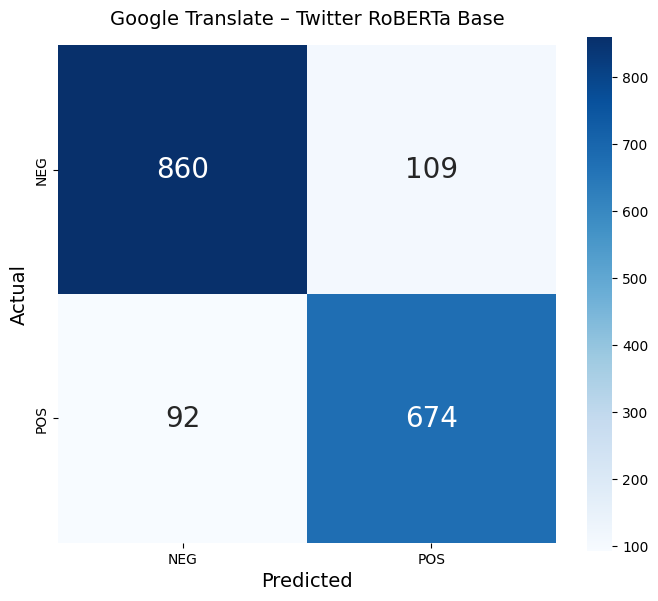


💾 Kaydedildi: /content/drive/MyDrive/NLP/Translation/figures/cm_google_roberta_binary.png
📁 Dosya var mı: True
📁 Boyut: 109605 byte


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

save_dir = "/content/drive/MyDrive/NLP/Translation/figures"
save_path = os.path.join(save_dir, "cm_google_roberta_binary.png")

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm_rb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
    cbar=True,
    square=True,
    annot_kws={"size": 20},
    ax=ax,
)
ax.set_xlabel("Predicted", fontsize=14)
ax.set_ylabel("Actual", fontsize=14)
ax.set_title("Google Translate – Twitter RoBERTa Base", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\n💾 Kaydedildi: {save_path}")
print(f"📁 Dosya var mı: {os.path.exists(save_path)}")
print(f"📁 Boyut: {os.path.getsize(save_path) if os.path.exists(save_path) else 0} byte")

In [ ]:
test_df_reset = test_df.reset_index(drop=True).copy()
test_df_reset["pred"] = y_pred_rb
test_df_reset["true"] = y_true_rb

lang_results_rb = {}
for lang in languages:
    sub = test_df_reset[test_df_reset["language"] == lang]
    yt = sub["true"].values
    yp = sub["pred"].values
    cm_lang = confusion_matrix(yt, yp, labels=[0, 1])
    TN_l, FP_l, FN_l, TP_l = cm_lang.ravel()
    spec_l = TN_l / (TN_l + FP_l) if (TN_l + FP_l) > 0 else 0
    lang_results_rb[lang_names[lang]] = {
        "Accuracy":    accuracy_score(yt, yp),
        "Precision":   precision_score(yt, yp, average="weighted", zero_division=0),
        "Recall":      recall_score(yt, yp, average="weighted", zero_division=0),
        "F1-Score":    f1_score(yt, yp, average="weighted", zero_division=0),
        "Specificity": spec_l,
    }

lang_df_rb = pd.DataFrame(lang_results_rb).round(4)
print("📊 Dil Bazlı — RoBERTa (Google, binary)\n")
print(lang_df_rb.to_string())

📊 Dil Bazlı — RoBERTa (Google, binary)

             Arabic  Chinese  French  Italian
Accuracy     0.8472   0.8824  0.9286   0.8728
Precision    0.8507   0.8824  0.9308   0.8729
Recall       0.8472   0.8824  0.9286   0.8728
F1-Score     0.8485   0.8823  0.9284   0.8715
Specificity  0.8713   0.8750  0.8865   0.9268


In [ ]:
MODEL_NAME = "vinai/bertweet-base"
MAX_LEN = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, normalization=True)

def tokenize_batch(batch):
    return tokenizer(
        batch["translated_text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
    )

print(f"✅ Tokenizer: {MODEL_NAME}")

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


✅ Tokenizer: vinai/bertweet-base


In [ ]:
cv_results_bertweet = []

for fold, (tr_idx, va_idx) in enumerate(
    skf.split(train_df["translated_text"], train_df["label"]), start=1
):
    print(f"\n📘 Fold {fold}/5...")

    tr_sub = train_df.iloc[tr_idx][["translated_text", "label"]]
    va_sub = train_df.iloc[va_idx][["translated_text", "label"]]

    tr_ds = Dataset.from_pandas(tr_sub, preserve_index=False).map(
        tokenize_batch, batched=True, remove_columns=["translated_text"]
    )
    va_ds = Dataset.from_pandas(va_sub, preserve_index=False).map(
        tokenize_batch, batched=True, remove_columns=["translated_text"]
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2, ignore_mismatched_sizes=True
    )

    args = TrainingArguments(
        output_dir=f"/content/bertweet_bin_cv/fold_{fold}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=3,
        weight_decay=0.01,
        warmup_ratio=0.1,
        logging_strategy="epoch",
        report_to="none",
        load_best_model_at_end=True,
        metric_for_best_model="f1_weighted",
        greater_is_better=True,
        save_total_limit=1,
        bf16=True,
        dataloader_num_workers=2,
        seed=SEED,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tr_ds,
        eval_dataset=va_ds,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics_fn,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer.train()
    metrics = trainer.evaluate()
    print(f"📊 Fold {fold}: F1={metrics['eval_f1_weighted']:.4f}, Acc={metrics['eval_accuracy']:.4f}")
    cv_results_bertweet.append(metrics)

    del model, trainer, tr_ds, va_ds
    gc.collect()
    torch.cuda.empty_cache()

print("\n✅ BERTweet 5-Fold CV (binary) tamamlandı.")

cv_f1_mean = np.mean([m["eval_f1_weighted"] for m in cv_results_bertweet])
cv_f1_std  = np.std([m["eval_f1_weighted"] for m in cv_results_bertweet])
print(f"📊 CV F1 ortalama: {cv_f1_mean:.4f} ± {cv_f1_std:.4f}")


📘 Fold 1/5...


Map:   0%|          | 0/5550 [00:00<?, ? examples/s]

Map:   0%|          | 0/1388 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_2854/2465120664.py:43: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision W,Recall W,F1 Weighted,Specificity
1,0.417900,0.336724,0.862392,0.869520,0.862392,0.862874,0.823454
2,0.249200,0.358451,0.888329,0.888660,0.888329,0.887916,0.922680
3,0.167400,0.396252,0.889049,0.889396,0.889049,0.889155,0.893041


...

Map:   0%|          | 0/5551 [00:00<?, ? examples/s]

Map:   0%|          | 0/1387 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_2854/2465120664.py:43: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision W,Recall W,F1 Weighted,Specificity
1,0.414800,0.294355,0.887527,0.889122,0.887527,0.887790,0.877577
2,0.245200,0.299697,0.901947,0.901947,0.901947,0.901947,0.912371
3,0.169000,0.355530,0.890411,0.891018,0.890411,0.890563,0.890464


📊 Fold 5: F1=0.9019, Acc=0.9019

✅ BERTweet 5-Fold CV (binary) tamamlandı.
📊 CV F1 ortalama: 0.8974 ± 0.0045


In [ ]:
full_train_ds = Dataset.from_pandas(
    train_df[["translated_text", "label"]], preserve_index=False
).map(tokenize_batch, batched=True, remove_columns=["translated_text"])

test_ds = Dataset.from_pandas(
    test_df[["translated_text", "label"]], preserve_index=False
).map(tokenize_batch, batched=True, remove_columns=["translated_text"])

final_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, ignore_mismatched_sizes=True
)

final_args = TrainingArguments(
    output_dir="/content/bertweet_bin_final",
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_strategy="epoch",
    save_strategy="no",
    report_to="none",
    bf16=True,
    seed=SEED,
)

final_trainer = Trainer(
    model=final_model,
    args=final_args,
    train_dataset=full_train_ds,
    tokenizer=tokenizer,
)

final_trainer.train()

pred_out = final_trainer.predict(test_ds)
y_true_bw = pred_out.label_ids
y_pred_bw = np.argmax(pred_out.predictions, axis=-1)
probs_bw = torch.softmax(torch.tensor(pred_out.predictions), dim=-1).numpy()

print(f"\n📊 BERTweet Test (binary):")
print(f"  F1:  {f1_score(y_true_bw, y_pred_bw, average='weighted'):.4f}")
print(f"  Acc: {accuracy_score(y_true_bw, y_pred_bw):.4f}")

bertweet_save = os.path.join(save_root, "bertweet_google_binary")
final_trainer.save_model(bertweet_save)
tokenizer.save_pretrained(bertweet_save)
np.save(os.path.join(save_root, "probs_bertweet_google.npy"), probs_bw)
print(f"💾 Kaydedildi: {bertweet_save}")

del final_model, final_trainer
gc.collect()
torch.cuda.empty_cache()

Map:   0%|          | 0/6938 [00:00<?, ? examples/s]

Map:   0%|          | 0/1735 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_2854/1835286511.py:28: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  final_trainer = Trainer(


Step,Training Loss
434,0.403300
868,0.245500
1302,0.172200



📊 BERTweet Test (binary):
  F1:  0.8831
  Acc: 0.8830
💾 Kaydedildi: /content/drive/MyDrive/NLP/Translation/final_models_binary/bertweet_google_binary


📊 Classification Report — BERTweet (Google, binary)

                    Accuracy  Precision  Recall  F1-Score  Specificity
NEG                      NaN     0.8998  0.8896    0.8947       0.8896
POS                      NaN     0.8623  0.8747    0.8684       0.8747
Overall (weighted)     0.883     0.8832  0.8830    0.8831       0.8896


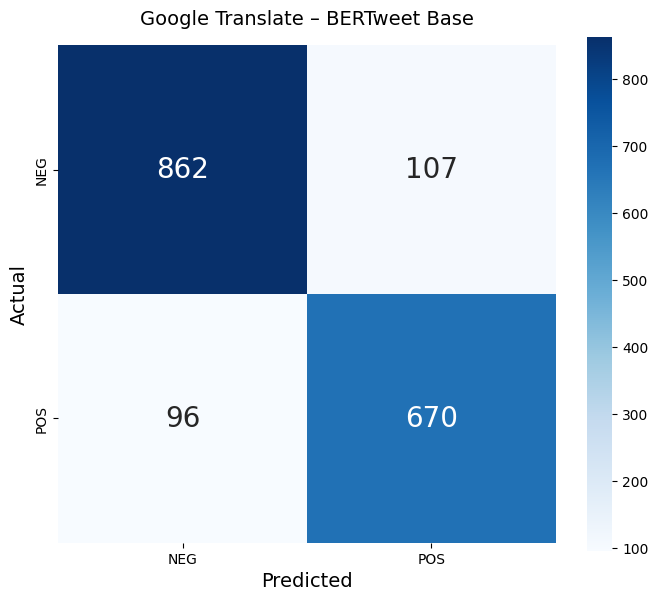


💾 CM Kaydedildi: /content/drive/MyDrive/NLP/Translation/figures/cm_google_bertweet_binary.png

📊 Dil Bazlı — BERTweet (Google, binary)

             Arabic  Chinese  French  Italian
Accuracy     0.8360   0.8803  0.9475   0.8580
Precision    0.8420   0.8802  0.9478   0.8576
Recall       0.8360   0.8803  0.9475   0.8580
F1-Score     0.8380   0.8802  0.9474   0.8567
Specificity  0.8548   0.8750  0.9301   0.9122


In [ ]:
cm_bw = confusion_matrix(y_true_bw, y_pred_bw, labels=[0, 1])
TN, FP, FN, TP = cm_bw.ravel()

per_class_bw = pd.DataFrame({
    "Accuracy":    [np.nan]*2,
    "Precision":   precision_score(y_true_bw, y_pred_bw, average=None, zero_division=0),
    "Recall":      recall_score(y_true_bw, y_pred_bw, average=None, zero_division=0),
    "F1-Score":    f1_score(y_true_bw, y_pred_bw, average=None, zero_division=0),
}, index=label_names)

spec_neg = TN / (TN + FP) if (TN + FP) > 0 else 0
spec_pos = TP / (TP + FN) if (TP + FN) > 0 else 0
per_class_bw["Specificity"] = [spec_neg, spec_pos]

overall_bw = pd.Series({
    "Accuracy":    accuracy_score(y_true_bw, y_pred_bw),
    "Precision":   precision_score(y_true_bw, y_pred_bw, average="weighted", zero_division=0),
    "Recall":      recall_score(y_true_bw, y_pred_bw, average="weighted", zero_division=0),
    "F1-Score":    f1_score(y_true_bw, y_pred_bw, average="weighted", zero_division=0),
    "Specificity": spec_neg,
}, name="Overall (weighted)")

report_bw = pd.concat([per_class_bw, overall_bw.to_frame().T])
print("📊 Classification Report — BERTweet (Google, binary)\n")
print(report_bw.round(4).to_string())

# Confusion matrix
save_path = os.path.join(save_dir, "cm_google_bertweet_binary.png")
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_bw, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names,
            cbar=True, square=True, annot_kws={"size": 20}, ax=ax)
ax.set_xlabel("Predicted", fontsize=14)
ax.set_ylabel("Actual", fontsize=14)
ax.set_title("Google Translate – BERTweet Base", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"\n💾 CM Kaydedildi: {save_path}")

# Dil bazlı
test_df_reset = test_df.reset_index(drop=True).copy()
test_df_reset["pred"] = y_pred_bw
test_df_reset["true"] = y_true_bw

lang_results_bw = {}
for lang in languages:
    sub = test_df_reset[test_df_reset["language"] == lang]
    yt = sub["true"].values
    yp = sub["pred"].values
    cm_lang = confusion_matrix(yt, yp, labels=[0, 1])
    TN_l, FP_l, FN_l, TP_l = cm_lang.ravel()
    spec_l = TN_l / (TN_l + FP_l) if (TN_l + FP_l) > 0 else 0
    lang_results_bw[lang_names[lang]] = {
        "Accuracy":    accuracy_score(yt, yp),
        "Precision":   precision_score(yt, yp, average="weighted", zero_division=0),
        "Recall":      recall_score(yt, yp, average="weighted", zero_division=0),
        "F1-Score":    f1_score(yt, yp, average="weighted", zero_division=0),
        "Specificity": spec_l,
    }

lang_df_bw = pd.DataFrame(lang_results_bw).round(4)
print("\n📊 Dil Bazlı — BERTweet (Google, binary)\n")
print(lang_df_bw.to_string())

In [ ]:
!pip install -q sentencepiece

MODEL_NAME = "microsoft/deberta-v3-base"
MAX_LEN = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(
        batch["translated_text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
    )

print(f"✅ Tokenizer: {MODEL_NAME}")

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


✅ Tokenizer: microsoft/deberta-v3-base


In [ ]:
cv_results_deberta = []

for fold, (tr_idx, va_idx) in enumerate(
    skf.split(train_df["translated_text"], train_df["label"]), start=1
):
    print(f"\n📘 Fold {fold}/5...")

    tr_sub = train_df.iloc[tr_idx][["translated_text", "label"]]
    va_sub = train_df.iloc[va_idx][["translated_text", "label"]]

    tr_ds = Dataset.from_pandas(tr_sub, preserve_index=False).map(
        tokenize_batch, batched=True, remove_columns=["translated_text"]
    )
    va_ds = Dataset.from_pandas(va_sub, preserve_index=False).map(
        tokenize_batch, batched=True, remove_columns=["translated_text"]
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2, ignore_mismatched_sizes=True
    )

    args = TrainingArguments(
        output_dir=f"/content/deberta_bin_cv/fold_{fold}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=3e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        gradient_accumulation_steps=2,
        num_train_epochs=3,
        weight_decay=0.01,
        warmup_ratio=0.1,
        logging_strategy="epoch",
        report_to="none",
        load_best_model_at_end=True,
        metric_for_best_model="f1_weighted",
        greater_is_better=True,
        save_total_limit=1,
        bf16=False,
        fp16=False,
        dataloader_num_workers=2,
        seed=SEED,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tr_ds,
        eval_dataset=va_ds,
        processing_class=tokenizer,
        compute_metrics=compute_metrics_fn,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer.train()
    metrics = trainer.evaluate()
    print(f"📊 Fold {fold}: F1={metrics['eval_f1_weighted']:.4f}, Acc={metrics['eval_accuracy']:.4f}")
    cv_results_deberta.append(metrics)

    del model, trainer, tr_ds, va_ds
    gc.collect()
    torch.cuda.empty_cache()

print("\n✅ DeBERTa 5-Fold CV (binary) tamamlandı.")

cv_f1_mean = np.mean([m["eval_f1_weighted"] for m in cv_results_deberta])
cv_f1_std  = np.std([m["eval_f1_weighted"] for m in cv_results_deberta])
print(f"📊 CV F1 ortalama: {cv_f1_mean:.4f} ± {cv_f1_std:.4f}")


📘 Fold 1/5...


Map:   0%|          | 0/5550 [00:00<?, ? examples/s]

Map:   0%|          | 0/1388 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Map:   0%|          | 0/5551 [00:00<?, ? examples/s]

Map:   0%|          | 0/1387 [00:00<?, ? examples/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision W,Recall W,F1 Weighted,Specificity
1,0.406800,0.301990,0.894016,0.895516,0.894016,0.894258,0.884021
2,0.232800,0.308789,0.888248,0.888812,0.888248,0.888396,0.889175
3,0.146300,0.457863,0.892574,0.892955,0.892574,0.892686,0.895619


📊 Fold 5: F1=0.8943, Acc=0.8940

✅ DeBERTa 5-Fold CV (binary) tamamlandı.
📊 CV F1 ortalama: 0.8965 ± 0.0070


In [ ]:
full_train_ds = Dataset.from_pandas(
    train_df[["translated_text", "label"]], preserve_index=False
).map(tokenize_batch, batched=True, remove_columns=["translated_text"])

test_ds = Dataset.from_pandas(
    test_df[["translated_text", "label"]], preserve_index=False
).map(tokenize_batch, batched=True, remove_columns=["translated_text"])

final_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, ignore_mismatched_sizes=True
)

final_args = TrainingArguments(
    output_dir="/content/deberta_bin_final",
    num_train_epochs=3,
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_strategy="epoch",
    save_strategy="no",
    report_to="none",
    bf16=False,
    fp16=False,
    seed=SEED,
)

final_trainer = Trainer(
    model=final_model,
    args=final_args,
    train_dataset=full_train_ds,
    processing_class=tokenizer,
)

final_trainer.train()

pred_out = final_trainer.predict(test_ds)
y_true_db = pred_out.label_ids
y_pred_db = np.argmax(pred_out.predictions, axis=-1)
probs_db = torch.softmax(torch.tensor(pred_out.predictions), dim=-1).numpy()

print(f"\n📊 DeBERTa Test (binary):")
print(f"  F1:  {f1_score(y_true_db, y_pred_db, average='weighted'):.4f}")
print(f"  Acc: {accuracy_score(y_true_db, y_pred_db):.4f}")

deberta_save = os.path.join(save_root, "deberta_google_binary")
final_trainer.save_model(deberta_save)
tokenizer.save_pretrained(deberta_save)
np.save(os.path.join(save_root, "probs_deberta_google.npy"), probs_db)
print(f"💾 Kaydedildi: {deberta_save}")

del final_model, final_trainer
gc.collect()
torch.cuda.empty_cache()

Map:   0%|          | 0/6938 [00:00<?, ? examples/s]

Map:   0%|          | 0/1735 [00:00<?, ? examples/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
434,0.389100
868,0.226800
1302,0.145000



📊 DeBERTa Test (binary):
  F1:  0.8775
  Acc: 0.8772
💾 Kaydedildi: /content/drive/MyDrive/NLP/Translation/final_models_binary/deberta_google_binary


📊 Classification Report — DeBERTa (Google, binary)

                    Accuracy  Precision  Recall  F1-Score  Specificity
NEG                      NaN     0.9056  0.8710    0.8880       0.8710
POS                      NaN     0.8443  0.8851    0.8642       0.8851
Overall (weighted)    0.8772     0.8785  0.8772    0.8775       0.8710


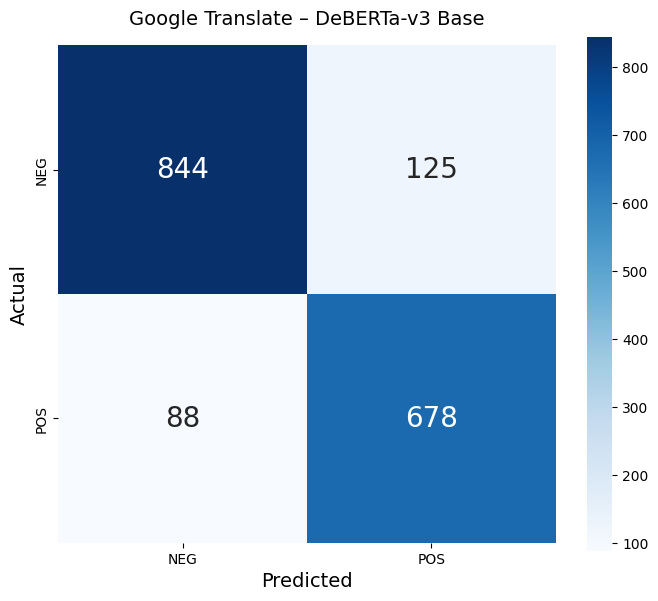


💾 CM Kaydedildi: /content/drive/MyDrive/NLP/Translation/figures/cm_google_deberta_binary.png

📊 Dil Bazlı — DeBERTa (Google, binary)

             Arabic  Chinese  French  Italian
Accuracy     0.8360   0.8761  0.9370   0.8491
Precision    0.8410   0.8763  0.9399   0.8486
Recall       0.8360   0.8761  0.9370   0.8491
F1-Score     0.8377   0.8760  0.9368   0.8488
Specificity  0.8581   0.8578  0.8908   0.8829


In [ ]:
cm_db = confusion_matrix(y_true_db, y_pred_db, labels=[0, 1])
TN, FP, FN, TP = cm_db.ravel()

per_class_db = pd.DataFrame({
    "Accuracy":    [np.nan]*2,
    "Precision":   precision_score(y_true_db, y_pred_db, average=None, zero_division=0),
    "Recall":      recall_score(y_true_db, y_pred_db, average=None, zero_division=0),
    "F1-Score":    f1_score(y_true_db, y_pred_db, average=None, zero_division=0),
}, index=label_names)

spec_neg = TN / (TN + FP) if (TN + FP) > 0 else 0
spec_pos = TP / (TP + FN) if (TP + FN) > 0 else 0
per_class_db["Specificity"] = [spec_neg, spec_pos]

overall_db = pd.Series({
    "Accuracy":    accuracy_score(y_true_db, y_pred_db),
    "Precision":   precision_score(y_true_db, y_pred_db, average="weighted", zero_division=0),
    "Recall":      recall_score(y_true_db, y_pred_db, average="weighted", zero_division=0),
    "F1-Score":    f1_score(y_true_db, y_pred_db, average="weighted", zero_division=0),
    "Specificity": spec_neg,
}, name="Overall (weighted)")

report_db = pd.concat([per_class_db, overall_db.to_frame().T])
print("📊 Classification Report — DeBERTa (Google, binary)\n")
print(report_db.round(4).to_string())

# Confusion matrix
save_path = os.path.join(save_dir, "cm_google_deberta_binary.png")
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_db, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names,
            cbar=True, square=True, annot_kws={"size": 20}, ax=ax)
ax.set_xlabel("Predicted", fontsize=14)
ax.set_ylabel("Actual", fontsize=14)
ax.set_title("Google Translate – DeBERTa-v3 Base", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"\n💾 CM Kaydedildi: {save_path}")

# Dil bazlı
test_df_reset = test_df.reset_index(drop=True).copy()
test_df_reset["pred"] = y_pred_db
test_df_reset["true"] = y_true_db

lang_results_db = {}
for lang in languages:
    sub = test_df_reset[test_df_reset["language"] == lang]
    yt = sub["true"].values
    yp = sub["pred"].values
    cm_lang = confusion_matrix(yt, yp, labels=[0, 1])
    TN_l, FP_l, FN_l, TP_l = cm_lang.ravel()
    spec_l = TN_l / (TN_l + FP_l) if (TN_l + FP_l) > 0 else 0
    lang_results_db[lang_names[lang]] = {
        "Accuracy":    accuracy_score(yt, yp),
        "Precision":   precision_score(yt, yp, average="weighted", zero_division=0),
        "Recall":      recall_score(yt, yp, average="weighted", zero_division=0),
        "F1-Score":    f1_score(yt, yp, average="weighted", zero_division=0),
        "Specificity": spec_l,
    }

lang_df_db = pd.DataFrame(lang_results_db).round(4)
print("\n📊 Dil Bazlı — DeBERTa (Google, binary)\n")
print(lang_df_db.to_string())

In [ ]:
from collections import Counter

# CV F1 ortalamaları (weighted voting için ağırlıklar)
cv_f1_scores = {
    "roberta":  0.8986,
    "bertweet": 0.8974,
    "deberta":  0.8965,
}

# Saved probs'ları yükleyelim (memory'de zaten var ama netlik için)
# Memory'de: probs_rb, probs_bw, probs_db (hepsi shape (1735, 2))

# Hard preds
preds_hard = np.stack([
    probs_rb.argmax(axis=1),
    probs_bw.argmax(axis=1),
    probs_db.argmax(axis=1),
], axis=1)

# 1) Majority Voting (binary'de tie kırılması için preds_rb tercih edilir)
y_pred_majority = np.array([Counter(row).most_common(1)[0][0] for row in preds_hard])

# 2) Soft Voting (eşit ağırlık ortalama)
avg_probs = (probs_rb + probs_bw + probs_db) / 3
y_pred_soft = avg_probs.argmax(axis=1)

# 3) Weighted Voting (CV F1'lere göre)
w = np.array([cv_f1_scores["roberta"], cv_f1_scores["bertweet"], cv_f1_scores["deberta"]])
w = w / w.sum()
print(f"⚖️ Ağırlıklar: RoBERTa={w[0]:.4f}, BERTweet={w[1]:.4f}, DeBERTa={w[2]:.4f}")

weighted_probs = w[0] * probs_rb + w[1] * probs_bw + w[2] * probs_db
y_pred_weighted = weighted_probs.argmax(axis=1)

# Eval fonksiyonu (binary)
def eval_binary(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()
    spec = TN / (TN + FP) if (TN + FP) > 0 else 0
    return {
        "Accuracy":    accuracy_score(y_true, y_pred),
        "Precision":   precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall":      recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-Score":    f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Specificity": spec,
    }

y_true_ens = y_true_rb  # üçünde de aynı

results_ens = {
    "Majority Voting": eval_binary(y_true_ens, y_pred_majority),
    "Soft Voting":     eval_binary(y_true_ens, y_pred_soft),
    "Weighted Voting": eval_binary(y_true_ens, y_pred_weighted),
}

ens_df = pd.DataFrame(results_ens).T
print("\n📊 Google Translate — Ensemble Karşılaştırması (binary)\n")
print(ens_df.round(4).to_string())

⚖️ Ağırlıklar: RoBERTa=0.3337, BERTweet=0.3333, DeBERTa=0.3330

📊 Google Translate — Ensemble Karşılaştırması (binary)

                 Accuracy  Precision  Recall  F1-Score  Specificity
Majority Voting    0.8859     0.8863  0.8859    0.8860       0.8896
Soft Voting        0.8865     0.8869  0.8865    0.8866       0.8885
Weighted Voting    0.8865     0.8869  0.8865    0.8866       0.8885


📊 Classification Report — Majority Voting Ensemble (Google, binary)

                    Accuracy  Precision  Recall  F1-Score  Specificity
NEG                      NaN     0.9045  0.8896    0.8970       0.8896
POS                      NaN     0.8632  0.8812    0.8721       0.8812
Overall (weighted)    0.8859     0.8863  0.8859    0.8860       0.8896


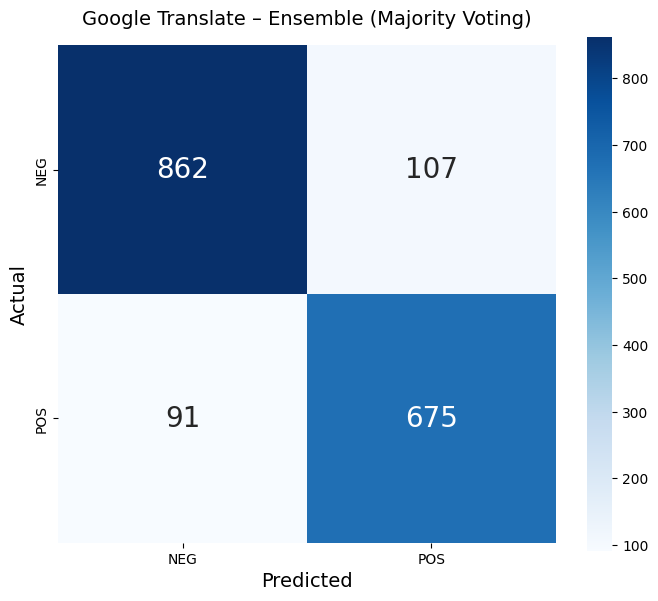


💾 CM Kaydedildi: /content/drive/MyDrive/NLP/Translation/figures/cm_google_ensemble_majority_binary.png

📊 Dil Bazlı — Majority Voting Ensemble (Google, binary)

             Arabic  Chinese  French  Italian
Accuracy     0.8382   0.8824  0.9475   0.8669
Precision    0.8428   0.8824  0.9487   0.8669
Recall       0.8382   0.8824  0.9475   0.8669
F1-Score     0.8398   0.8823  0.9474   0.8655
Specificity  0.8614   0.8707  0.9170   0.9220


In [ ]:
# ANA YÖNTEM: Majority Voting
y_pred_ens = y_pred_majority

# Classification report
cm_ens = confusion_matrix(y_true_ens, y_pred_ens, labels=[0, 1])
TN, FP, FN, TP = cm_ens.ravel()

per_class_ens = pd.DataFrame({
    "Accuracy":    [np.nan]*2,
    "Precision":   precision_score(y_true_ens, y_pred_ens, average=None, zero_division=0),
    "Recall":      recall_score(y_true_ens, y_pred_ens, average=None, zero_division=0),
    "F1-Score":    f1_score(y_true_ens, y_pred_ens, average=None, zero_division=0),
}, index=label_names)

spec_neg = TN / (TN + FP) if (TN + FP) > 0 else 0
spec_pos = TP / (TP + FN) if (TP + FN) > 0 else 0
per_class_ens["Specificity"] = [spec_neg, spec_pos]

overall_ens = pd.Series({
    "Accuracy":    accuracy_score(y_true_ens, y_pred_ens),
    "Precision":   precision_score(y_true_ens, y_pred_ens, average="weighted", zero_division=0),
    "Recall":      recall_score(y_true_ens, y_pred_ens, average="weighted", zero_division=0),
    "F1-Score":    f1_score(y_true_ens, y_pred_ens, average="weighted", zero_division=0),
    "Specificity": spec_neg,
}, name="Overall (weighted)")

report_ens = pd.concat([per_class_ens, overall_ens.to_frame().T])
print("📊 Classification Report — Majority Voting Ensemble (Google, binary)\n")
print(report_ens.round(4).to_string())

# Confusion matrix
save_path = os.path.join(save_dir, "cm_google_ensemble_majority_binary.png")
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_ens, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names,
            cbar=True, square=True, annot_kws={"size": 20}, ax=ax)
ax.set_xlabel("Predicted", fontsize=14)
ax.set_ylabel("Actual", fontsize=14)
ax.set_title("Google Translate – Ensemble (Majority Voting)", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"\n💾 CM Kaydedildi: {save_path}")

# Dil bazlı
test_df_reset = test_df.reset_index(drop=True).copy()
test_df_reset["pred"] = y_pred_ens
test_df_reset["true"] = y_true_ens

lang_results_ens = {}
for lang in languages:
    sub = test_df_reset[test_df_reset["language"] == lang]
    yt = sub["true"].values
    yp = sub["pred"].values
    cm_lang = confusion_matrix(yt, yp, labels=[0, 1])
    TN_l, FP_l, FN_l, TP_l = cm_lang.ravel()
    spec_l = TN_l / (TN_l + FP_l) if (TN_l + FP_l) > 0 else 0
    lang_results_ens[lang_names[lang]] = {
        "Accuracy":    accuracy_score(yt, yp),
        "Precision":   precision_score(yt, yp, average="weighted", zero_division=0),
        "Recall":      recall_score(yt, yp, average="weighted", zero_division=0),
        "F1-Score":    f1_score(yt, yp, average="weighted", zero_division=0),
        "Specificity": spec_l,
    }

lang_df_ens = pd.DataFrame(lang_results_ens).round(4)
print("\n📊 Dil Bazlı — Majority Voting Ensemble (Google, binary)\n")
print(lang_df_ens.to_string())

In [ ]:
import os

save_root = "/content/drive/MyDrive/NLP/Translation/final_models_binary"
print(f"📂 {save_root}:\n")

if os.path.exists(save_root):
    for item in sorted(os.listdir(save_root)):
        path = os.path.join(save_root, item)
        if os.path.isdir(path):
            print(f"📁 {item}/")
            for f in sorted(os.listdir(path)):
                size = os.path.getsize(os.path.join(path, f))
                print(f"   {f} ({size/1e6:.1f} MB)")
        else:
            size = os.path.getsize(path)
            print(f"📄 {item} ({size/1e6:.2f} MB)")
else:
    print("❌ Klasör yok!")

📂 /content/drive/MyDrive/NLP/Translation/final_models_binary:

📁 bertweet_google_binary/
   added_tokens.json (0.0 MB)
   bpe.codes (1.1 MB)
   config.json (0.0 MB)
   model.safetensors (539.6 MB)
   special_tokens_map.json (0.0 MB)
   tokenizer_config.json (0.0 MB)
   training_args.bin (0.0 MB)
   vocab.txt (0.8 MB)
📁 deberta_google_binary/
   added_tokens.json (0.0 MB)
   config.json (0.0 MB)
   model.safetensors (737.7 MB)
   special_tokens_map.json (0.0 MB)
   spm.model (2.5 MB)
   tokenizer.json (8.7 MB)
   tokenizer_config.json (0.0 MB)
   training_args.bin (0.0 MB)
📄 probs_bertweet_google.npy (0.01 MB)
📄 probs_deberta_google.npy (0.01 MB)
📄 probs_roberta_google.npy (0.01 MB)
📁 roberta_google_binary/
   config.json (0.0 MB)
   merges.txt (0.5 MB)
   model.safetensors (498.6 MB)
   special_tokens_map.json (0.0 MB)
   tokenizer.json (3.6 MB)
   tokenizer_config.json (0.0 MB)
   training_args.bin (0.0 MB)
   vocab.json (0.8 MB)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

SEED = 42
np.random.seed(SEED)

DATA_PATH = "/content/drive/MyDrive/NLP/Translation/merged_datasets/merged_balanced_translated_libre_fixed.csv"

df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=["translated_text", "sentiment"]).copy()
df["translated_text"] = df["translated_text"].astype(str)

# Duplicate temizliği
before = len(df)
df = df.drop_duplicates(subset=["translated_text"]).reset_index(drop=True)
print(f"🧹 Duplicate temizliği: {before} → {len(df)}")

# NEUTRAL çıkar
before = len(df)
df = df[df["sentiment"] != "NEUTRAL"].reset_index(drop=True)
print(f"🧹 NEUTRAL çıkarıldı: {before} → {len(df)}")

# Binary label
label_map = {"NEG": 0, "POS": 1}
label_names = ["NEG", "POS"]
df["label"] = df["sentiment"].map(label_map).astype(int)

print(f"\n📊 Binary dataset: {df.shape}")
print(f"\n🎯 Sınıf dağılımı:\n{df['sentiment'].value_counts()}")
print(f"\n🌍 Dil dağılımı:\n{df['language'].value_counts()}")

Mounted at /content/drive
🧹 Duplicate temizliği: 12000 → 11781
🧹 NEUTRAL çıkarıldı: 11781 → 8536

📊 Binary dataset: (8536, 5)

🎯 Sınıf dağılımı:
sentiment
NEG    4810
POS    3726
Name: count, dtype: int64

🌍 Dil dağılımı:
language
fr    2379
zh    2272
ar    2222
it    1663
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

strat_key = df["language"].astype(str) + "_" + df["label"].astype(str)

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    stratify=strat_key,
    random_state=SEED,
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"✅ Train: {train_df.shape}")
print(f"✅ Test:  {test_df.shape}")

overlap = set(train_df["translated_text"]).intersection(set(test_df["translated_text"]))
print(f"⚠️ Train-Test ortak: {len(overlap)} (0 olmalı)")

TRAIN_SAVE = "/content/drive/MyDrive/NLP/Translation/merged_datasets/holdout_train_libre_binary.csv"
TEST_SAVE  = "/content/drive/MyDrive/NLP/Translation/merged_datasets/holdout_test_libre_binary.csv"
train_df.to_csv(TRAIN_SAVE, index=False, encoding="utf-8")
test_df.to_csv(TEST_SAVE, index=False, encoding="utf-8")
print(f"\n💾 Kaydedildi.")

✅ Train: (6828, 5)
✅ Test:  (1708, 5)
⚠️ Train-Test ortak: 0 (0 olmalı)

💾 Kaydedildi.


In [ ]:
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
)

def compute_metrics_fn(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=-1)
    cm = confusion_matrix(labels, preds, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()
    spec = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    return {
        "accuracy":    accuracy_score(labels, preds),
        "precision_w": precision_score(labels, preds, average="weighted", zero_division=0),
        "recall_w":    recall_score(labels, preds, average="weighted", zero_division=0),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "specificity": spec,
    }

languages = ["ar", "zh", "fr", "it"]
lang_names = {"ar": "Arabic", "zh": "Chinese", "fr": "French", "it": "Italian"}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"💻 Device: {device}")

💻 Device: cuda


In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment"
MAX_LEN = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(
        batch["translated_text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
    )

print(f"✅ Tokenizer: {MODEL_NAME}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

✅ Tokenizer: cardiffnlp/twitter-roberta-base-sentiment


In [ ]:
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from datasets import Dataset
import torch, gc

cv_results_roberta = []

for fold, (tr_idx, va_idx) in enumerate(
    skf.split(train_df["translated_text"], train_df["label"]), start=1
):
    print(f"\n📘 Fold {fold}/5...")

    tr_sub = train_df.iloc[tr_idx][["translated_text", "label"]]
    va_sub = train_df.iloc[va_idx][["translated_text", "label"]]

    tr_ds = Dataset.from_pandas(tr_sub, preserve_index=False).map(
        tokenize_batch, batched=True, remove_columns=["translated_text"]
    )
    va_ds = Dataset.from_pandas(va_sub, preserve_index=False).map(
        tokenize_batch, batched=True, remove_columns=["translated_text"]
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2, ignore_mismatched_sizes=True
    )

    args = TrainingArguments(
        output_dir=f"/content/roberta_libre_cv/fold_{fold}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=3,
        weight_decay=0.01,
        warmup_ratio=0.1,
        logging_strategy="epoch",
        report_to="none",
        load_best_model_at_end=True,
        metric_for_best_model="f1_weighted",
        greater_is_better=True,
        save_total_limit=1,
        bf16=True,
        dataloader_num_workers=2,
        seed=SEED,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tr_ds,
        eval_dataset=va_ds,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics_fn,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer.train()
    metrics = trainer.evaluate()
    print(f"📊 Fold {fold}: F1={metrics['eval_f1_weighted']:.4f}, Acc={metrics['eval_accuracy']:.4f}")
    cv_results_roberta.append(metrics)

    del model, trainer, tr_ds, va_ds
    gc.collect()
    torch.cuda.empty_cache()

print("\n✅ RoBERTa 5-Fold CV (Libre, binary) tamamlandı.")

cv_f1_mean = np.mean([m["eval_f1_weighted"] for m in cv_results_roberta])
cv_f1_std  = np.std([m["eval_f1_weighted"] for m in cv_results_roberta])
print(f"📊 CV F1 ortalama: {cv_f1_mean:.4f} ± {cv_f1_std:.4f}")


📘 Fold 1/5...


Map:   0%|          | 0/5462 [00:00<?, ? examples/s]

Map:   0%|          | 0/1366 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([2]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_1604/2049474995.py:52: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Map:   0%|          | 0/5463 [00:00<?, ? examples/s]

Map:   0%|          | 0/1365 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([2]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_1604/2049474995.py:52: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision W,Recall W,F1 Weighted,Specificity
1,0.413000,0.364198,0.852747,0.852776,0.852747,0.852761,0.868661
2,0.282500,0.356254,0.856410,0.856846,0.856410,0.856561,0.864759
3,0.191400,0.452761,0.861538,0.863732,0.861538,0.861931,0.851756


📊 Fold 5: F1=0.8619, Acc=0.8615

✅ RoBERTa 5-Fold CV (Libre, binary) tamamlandı.
📊 CV F1 ortalama: 0.8539 ± 0.0075


In [ ]:
full_train_ds = Dataset.from_pandas(
    train_df[["translated_text", "label"]], preserve_index=False
).map(tokenize_batch, batched=True, remove_columns=["translated_text"])

test_ds = Dataset.from_pandas(
    test_df[["translated_text", "label"]], preserve_index=False
).map(tokenize_batch, batched=True, remove_columns=["translated_text"])

final_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, ignore_mismatched_sizes=True
)

final_args = TrainingArguments(
    output_dir="/content/roberta_libre_final",
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_strategy="epoch",
    save_strategy="no",
    report_to="none",
    bf16=True,
    seed=SEED,
)

final_trainer = Trainer(
    model=final_model,
    args=final_args,
    train_dataset=full_train_ds,
    tokenizer=tokenizer,
)

final_trainer.train()

pred_out = final_trainer.predict(test_ds)
y_true_rb = pred_out.label_ids
y_pred_rb = np.argmax(pred_out.predictions, axis=-1)
probs_rb = torch.softmax(torch.tensor(pred_out.predictions), dim=-1).numpy()

print(f"\n📊 RoBERTa Test (Libre, binary):")
print(f"  F1:  {f1_score(y_true_rb, y_pred_rb, average='weighted'):.4f}")
print(f"  Acc: {accuracy_score(y_true_rb, y_pred_rb):.4f}")

import os
save_root = "/content/drive/MyDrive/NLP/Translation/final_models_binary"
os.makedirs(save_root, exist_ok=True)
roberta_save = os.path.join(save_root, "roberta_libre_binary")
final_trainer.save_model(roberta_save)
tokenizer.save_pretrained(roberta_save)
np.save(os.path.join(save_root, "probs_roberta_libre.npy"), probs_rb)
print(f"💾 Kaydedildi.")

del final_model, final_trainer
gc.collect()
torch.cuda.empty_cache()

Map:   0%|          | 0/6828 [00:00<?, ? examples/s]

Map:   0%|          | 0/1708 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([2]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_1604/1293659027.py:28: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  final_trainer = Trainer(


Step,Training Loss
427,0.404100
854,0.277000
1281,0.190800



📊 RoBERTa Test (Libre, binary):
  F1:  0.8311
  Acc: 0.8314
💾 Kaydedildi.


📊 Classification Report — RoBERTa (Libre, binary)

                    Accuracy  Precision  Recall  F1-Score  Specificity
NEG                      NaN     0.8439  0.8597    0.8517       0.8597
POS                      NaN     0.8146  0.7949    0.8046       0.7949
Overall (weighted)    0.8314     0.8311  0.8314    0.8311       0.8597


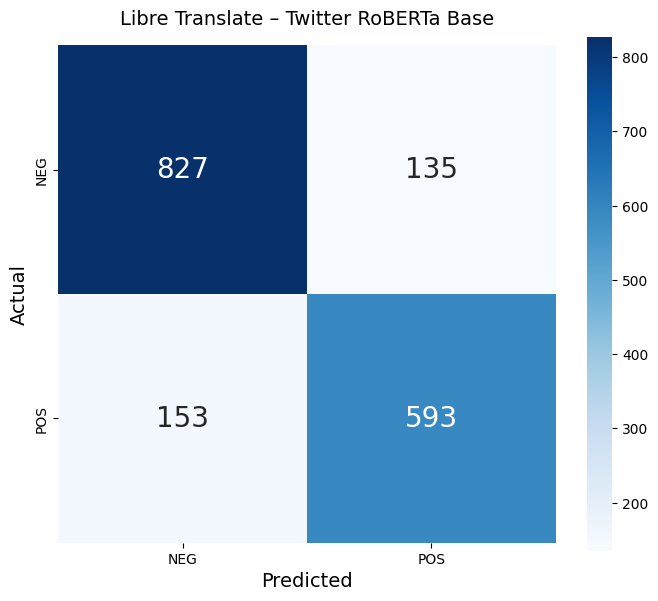


💾 CM Kaydedildi: /content/drive/MyDrive/NLP/Translation/figures/cm_libre_roberta_binary.png

📊 Dil Bazlı — RoBERTa (Libre, binary)

             Arabic  Chinese  French  Italian
Accuracy     0.8022   0.7846  0.9286   0.7952
Precision    0.7986   0.7850  0.9290   0.7938
Recall       0.8022   0.7846  0.9286   0.7952
F1-Score     0.7998   0.7846  0.9285   0.7942
Specificity  0.8746   0.8018  0.9083   0.8473


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

save_dir = "/content/drive/MyDrive/NLP/Translation/figures"
os.makedirs(save_dir, exist_ok=True)

cm_rb = confusion_matrix(y_true_rb, y_pred_rb, labels=[0, 1])
TN, FP, FN, TP = cm_rb.ravel()

per_class_rb = pd.DataFrame({
    "Accuracy":    [np.nan]*2,
    "Precision":   precision_score(y_true_rb, y_pred_rb, average=None, zero_division=0),
    "Recall":      recall_score(y_true_rb, y_pred_rb, average=None, zero_division=0),
    "F1-Score":    f1_score(y_true_rb, y_pred_rb, average=None, zero_division=0),
}, index=label_names)

spec_neg = TN / (TN + FP) if (TN + FP) > 0 else 0
spec_pos = TP / (TP + FN) if (TP + FN) > 0 else 0
per_class_rb["Specificity"] = [spec_neg, spec_pos]

overall_rb = pd.Series({
    "Accuracy":    accuracy_score(y_true_rb, y_pred_rb),
    "Precision":   precision_score(y_true_rb, y_pred_rb, average="weighted", zero_division=0),
    "Recall":      recall_score(y_true_rb, y_pred_rb, average="weighted", zero_division=0),
    "F1-Score":    f1_score(y_true_rb, y_pred_rb, average="weighted", zero_division=0),
    "Specificity": spec_neg,
}, name="Overall (weighted)")

report_rb = pd.concat([per_class_rb, overall_rb.to_frame().T])
print("📊 Classification Report — RoBERTa (Libre, binary)\n")
print(report_rb.round(4).to_string())

# CM
save_path = os.path.join(save_dir, "cm_libre_roberta_binary.png")
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_rb, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names,
            cbar=True, square=True, annot_kws={"size": 20}, ax=ax)
ax.set_xlabel("Predicted", fontsize=14)
ax.set_ylabel("Actual", fontsize=14)
ax.set_title("Libre Translate – Twitter RoBERTa Base", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"\n💾 CM Kaydedildi: {save_path}")

# Dil bazlı
test_df_reset = test_df.reset_index(drop=True).copy()
test_df_reset["pred"] = y_pred_rb
test_df_reset["true"] = y_true_rb

lang_results_rb = {}
for lang in languages:
    sub = test_df_reset[test_df_reset["language"] == lang]
    yt = sub["true"].values
    yp = sub["pred"].values
    cm_lang = confusion_matrix(yt, yp, labels=[0, 1])
    TN_l, FP_l, FN_l, TP_l = cm_lang.ravel()
    spec_l = TN_l / (TN_l + FP_l) if (TN_l + FP_l) > 0 else 0
    lang_results_rb[lang_names[lang]] = {
        "Accuracy":    accuracy_score(yt, yp),
        "Precision":   precision_score(yt, yp, average="weighted", zero_division=0),
        "Recall":      recall_score(yt, yp, average="weighted", zero_division=0),
        "F1-Score":    f1_score(yt, yp, average="weighted", zero_division=0),
        "Specificity": spec_l,
    }

lang_df_rb = pd.DataFrame(lang_results_rb).round(4)
print("\n📊 Dil Bazlı — RoBERTa (Libre, binary)\n")
print(lang_df_rb.to_string())

In [ ]:
MODEL_NAME = "vinai/bertweet-base"
MAX_LEN = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, normalization=True)

def tokenize_batch(batch):
    return tokenizer(
        batch["translated_text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
    )

print(f"✅ Tokenizer: {MODEL_NAME}")

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


✅ Tokenizer: vinai/bertweet-base


In [ ]:
cv_results_bertweet = []

for fold, (tr_idx, va_idx) in enumerate(
    skf.split(train_df["translated_text"], train_df["label"]), start=1
):
    print(f"\n📘 Fold {fold}/5...")

    tr_sub = train_df.iloc[tr_idx][["translated_text", "label"]]
    va_sub = train_df.iloc[va_idx][["translated_text", "label"]]

    tr_ds = Dataset.from_pandas(tr_sub, preserve_index=False).map(
        tokenize_batch, batched=True, remove_columns=["translated_text"]
    )
    va_ds = Dataset.from_pandas(va_sub, preserve_index=False).map(
        tokenize_batch, batched=True, remove_columns=["translated_text"]
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2, ignore_mismatched_sizes=True
    )

    args = TrainingArguments(
        output_dir=f"/content/bertweet_libre_cv/fold_{fold}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=3,
        weight_decay=0.01,
        warmup_ratio=0.1,
        logging_strategy="epoch",
        report_to="none",
        load_best_model_at_end=True,
        metric_for_best_model="f1_weighted",
        greater_is_better=True,
        save_total_limit=1,
        bf16=True,
        dataloader_num_workers=2,
        seed=SEED,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tr_ds,
        eval_dataset=va_ds,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics_fn,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer.train()
    metrics = trainer.evaluate()
    print(f"📊 Fold {fold}: F1={metrics['eval_f1_weighted']:.4f}, Acc={metrics['eval_accuracy']:.4f}")
    cv_results_bertweet.append(metrics)

    del model, trainer, tr_ds, va_ds
    gc.collect()
    torch.cuda.empty_cache()

print("\n✅ BERTweet 5-Fold CV (Libre, binary) tamamlandı.")

cv_f1_mean = np.mean([m["eval_f1_weighted"] for m in cv_results_bertweet])
cv_f1_std  = np.std([m["eval_f1_weighted"] for m in cv_results_bertweet])
print(f"📊 CV F1 ortalama: {cv_f1_mean:.4f} ± {cv_f1_std:.4f}")


📘 Fold 1/5...


Map:   0%|          | 0/5462 [00:00<?, ? examples/s]

Map:   0%|          | 0/1366 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_1604/578254690.py:43: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Map:   0%|          | 0/5463 [00:00<?, ? examples/s]

Map:   0%|          | 0/1365 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_1604/578254690.py:43: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision W,Recall W,F1 Weighted,Specificity
1,0.482500,0.407674,0.849084,0.855925,0.849084,0.846381,0.938882
2,0.305700,0.378960,0.862271,0.862455,0.862271,0.862346,0.873862
3,0.224900,0.425679,0.852015,0.853530,0.852015,0.852359,0.849155


📊 Fold 5: F1=0.8623, Acc=0.8623

✅ BERTweet 5-Fold CV (Libre, binary) tamamlandı.
📊 CV F1 ortalama: 0.8524 ± 0.0067


In [ ]:
full_train_ds = Dataset.from_pandas(
    train_df[["translated_text", "label"]], preserve_index=False
).map(tokenize_batch, batched=True, remove_columns=["translated_text"])

test_ds = Dataset.from_pandas(
    test_df[["translated_text", "label"]], preserve_index=False
).map(tokenize_batch, batched=True, remove_columns=["translated_text"])

final_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, ignore_mismatched_sizes=True
)

final_args = TrainingArguments(
    output_dir="/content/bertweet_libre_final",
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_strategy="epoch",
    save_strategy="no",
    report_to="none",
    bf16=True,
    seed=SEED,
)

final_trainer = Trainer(
    model=final_model,
    args=final_args,
    train_dataset=full_train_ds,
    tokenizer=tokenizer,
)

final_trainer.train()

pred_out = final_trainer.predict(test_ds)
y_true_bw = pred_out.label_ids
y_pred_bw = np.argmax(pred_out.predictions, axis=-1)
probs_bw = torch.softmax(torch.tensor(pred_out.predictions), dim=-1).numpy()

print(f"\n📊 BERTweet Test (Libre, binary):")
print(f"  F1:  {f1_score(y_true_bw, y_pred_bw, average='weighted'):.4f}")
print(f"  Acc: {accuracy_score(y_true_bw, y_pred_bw):.4f}")

bertweet_save = os.path.join(save_root, "bertweet_libre_binary")
final_trainer.save_model(bertweet_save)
tokenizer.save_pretrained(bertweet_save)
np.save(os.path.join(save_root, "probs_bertweet_libre.npy"), probs_bw)
print(f"💾 Kaydedildi.")

del final_model, final_trainer
gc.collect()
torch.cuda.empty_cache()

Map:   0%|          | 0/6828 [00:00<?, ? examples/s]

Map:   0%|          | 0/1708 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_1604/3683548117.py:28: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  final_trainer = Trainer(


Step,Training Loss
427,0.476300
854,0.311100
1281,0.219600



📊 BERTweet Test (Libre, binary):
  F1:  0.8303
  Acc: 0.8302
💾 Kaydedildi.


📊 Classification Report — BERTweet (Libre, binary)

                    Accuracy  Precision  Recall  F1-Score  Specificity
NEG                      NaN     0.8507  0.8472    0.8490       0.8472
POS                      NaN     0.8040  0.8083    0.8061       0.8083
Overall (weighted)    0.8302     0.8303  0.8302    0.8303       0.8472


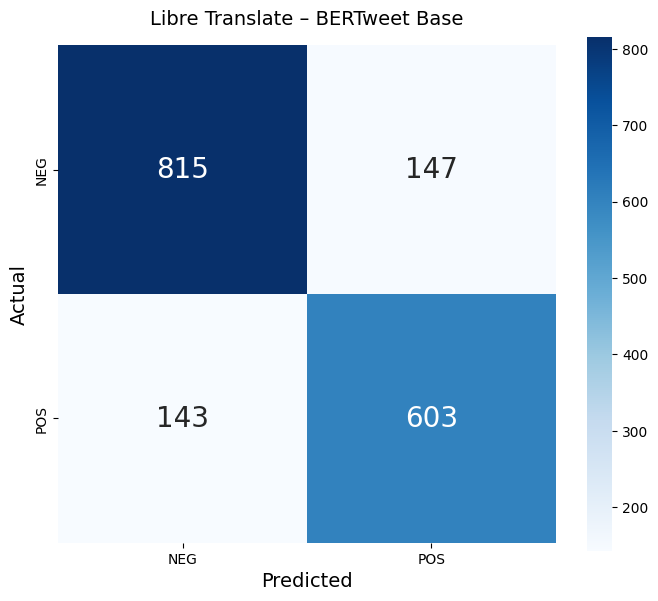


💾 CM Kaydedildi: /content/drive/MyDrive/NLP/Translation/figures/cm_libre_bertweet_binary.png

📊 Dil Bazlı — BERTweet (Libre, binary)

             Arabic  Chinese  French  Italian
Accuracy     0.7910   0.7736  0.9265   0.8223
Precision    0.7899   0.7741  0.9273   0.8238
Recall       0.7910   0.7736  0.9265   0.8223
F1-Score     0.7904   0.7735  0.9264   0.8229
Specificity  0.8515   0.7930  0.8996   0.8424


In [ ]:
cm_bw = confusion_matrix(y_true_bw, y_pred_bw, labels=[0, 1])
TN, FP, FN, TP = cm_bw.ravel()

per_class_bw = pd.DataFrame({
    "Accuracy":    [np.nan]*2,
    "Precision":   precision_score(y_true_bw, y_pred_bw, average=None, zero_division=0),
    "Recall":      recall_score(y_true_bw, y_pred_bw, average=None, zero_division=0),
    "F1-Score":    f1_score(y_true_bw, y_pred_bw, average=None, zero_division=0),
}, index=label_names)

spec_neg = TN / (TN + FP) if (TN + FP) > 0 else 0
spec_pos = TP / (TP + FN) if (TP + FN) > 0 else 0
per_class_bw["Specificity"] = [spec_neg, spec_pos]

overall_bw = pd.Series({
    "Accuracy":    accuracy_score(y_true_bw, y_pred_bw),
    "Precision":   precision_score(y_true_bw, y_pred_bw, average="weighted", zero_division=0),
    "Recall":      recall_score(y_true_bw, y_pred_bw, average="weighted", zero_division=0),
    "F1-Score":    f1_score(y_true_bw, y_pred_bw, average="weighted", zero_division=0),
    "Specificity": spec_neg,
}, name="Overall (weighted)")

report_bw = pd.concat([per_class_bw, overall_bw.to_frame().T])
print("📊 Classification Report — BERTweet (Libre, binary)\n")
print(report_bw.round(4).to_string())

save_path = os.path.join(save_dir, "cm_libre_bertweet_binary.png")
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_bw, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names,
            cbar=True, square=True, annot_kws={"size": 20}, ax=ax)
ax.set_xlabel("Predicted", fontsize=14)
ax.set_ylabel("Actual", fontsize=14)
ax.set_title("Libre Translate – BERTweet Base", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"\n💾 CM Kaydedildi: {save_path}")

test_df_reset = test_df.reset_index(drop=True).copy()
test_df_reset["pred"] = y_pred_bw
test_df_reset["true"] = y_true_bw

lang_results_bw = {}
for lang in languages:
    sub = test_df_reset[test_df_reset["language"] == lang]
    yt = sub["true"].values
    yp = sub["pred"].values
    cm_lang = confusion_matrix(yt, yp, labels=[0, 1])
    TN_l, FP_l, FN_l, TP_l = cm_lang.ravel()
    spec_l = TN_l / (TN_l + FP_l) if (TN_l + FP_l) > 0 else 0
    lang_results_bw[lang_names[lang]] = {
        "Accuracy":    accuracy_score(yt, yp),
        "Precision":   precision_score(yt, yp, average="weighted", zero_division=0),
        "Recall":      recall_score(yt, yp, average="weighted", zero_division=0),
        "F1-Score":    f1_score(yt, yp, average="weighted", zero_division=0),
        "Specificity": spec_l,
    }

lang_df_bw = pd.DataFrame(lang_results_bw).round(4)
print("\n📊 Dil Bazlı — BERTweet (Libre, binary)\n")
print(lang_df_bw.to_string())

In [ ]:
!pip install -q sentencepiece

MODEL_NAME = "microsoft/deberta-v3-base"
MAX_LEN = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(
        batch["translated_text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
    )

print(f"✅ Tokenizer: {MODEL_NAME}")

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


✅ Tokenizer: microsoft/deberta-v3-base


In [ ]:
cv_results_deberta = []

for fold, (tr_idx, va_idx) in enumerate(
    skf.split(train_df["translated_text"], train_df["label"]), start=1
):
    print(f"\n📘 Fold {fold}/5...")

    tr_sub = train_df.iloc[tr_idx][["translated_text", "label"]]
    va_sub = train_df.iloc[va_idx][["translated_text", "label"]]

    tr_ds = Dataset.from_pandas(tr_sub, preserve_index=False).map(
        tokenize_batch, batched=True, remove_columns=["translated_text"]
    )
    va_ds = Dataset.from_pandas(va_sub, preserve_index=False).map(
        tokenize_batch, batched=True, remove_columns=["translated_text"]
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2, ignore_mismatched_sizes=True
    )

    args = TrainingArguments(
        output_dir=f"/content/deberta_libre_cv/fold_{fold}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=3e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        gradient_accumulation_steps=2,
        num_train_epochs=3,
        weight_decay=0.01,
        warmup_ratio=0.1,
        logging_strategy="epoch",
        report_to="none",
        load_best_model_at_end=True,
        metric_for_best_model="f1_weighted",
        greater_is_better=True,
        save_total_limit=1,
        bf16=False,
        fp16=False,
        dataloader_num_workers=2,
        seed=SEED,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tr_ds,
        eval_dataset=va_ds,
        processing_class=tokenizer,
        compute_metrics=compute_metrics_fn,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer.train()
    metrics = trainer.evaluate()
    print(f"📊 Fold {fold}: F1={metrics['eval_f1_weighted']:.4f}, Acc={metrics['eval_accuracy']:.4f}")
    cv_results_deberta.append(metrics)

    del model, trainer, tr_ds, va_ds
    gc.collect()
    torch.cuda.empty_cache()

print("\n✅ DeBERTa 5-Fold CV (Libre, binary) tamamlandı.")

cv_f1_mean = np.mean([m["eval_f1_weighted"] for m in cv_results_deberta])
cv_f1_std  = np.std([m["eval_f1_weighted"] for m in cv_results_deberta])
print(f"📊 CV F1 ortalama: {cv_f1_mean:.4f} ± {cv_f1_std:.4f}")


📘 Fold 1/5...


Map:   0%|          | 0/5462 [00:00<?, ? examples/s]

Map:   0%|          | 0/1366 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Map:   0%|          | 0/5463 [00:00<?, ? examples/s]

Map:   0%|          | 0/1365 [00:00<?, ? examples/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision W,Recall W,F1 Weighted,Specificity
0,0.480000,0.422800,0.857143,0.856963,0.857143,0.857015,0.879064
2,0.181000,0.542270,0.847619,0.849956,0.847619,0.848058,0.838752


📊 Fold 5: F1=0.8587, Acc=0.8586

✅ DeBERTa 5-Fold CV (Libre, binary) tamamlandı.
📊 CV F1 ortalama: 0.8544 ± 0.0093


In [ ]:
full_train_ds = Dataset.from_pandas(
    train_df[["translated_text", "label"]], preserve_index=False
).map(tokenize_batch, batched=True, remove_columns=["translated_text"])

test_ds = Dataset.from_pandas(
    test_df[["translated_text", "label"]], preserve_index=False
).map(tokenize_batch, batched=True, remove_columns=["translated_text"])

final_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, ignore_mismatched_sizes=True
)

final_args = TrainingArguments(
    output_dir="/content/deberta_libre_final",
    num_train_epochs=3,
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_strategy="epoch",
    save_strategy="no",
    report_to="none",
    bf16=False,
    fp16=False,
    seed=SEED,
)

final_trainer = Trainer(
    model=final_model,
    args=final_args,
    train_dataset=full_train_ds,
    processing_class=tokenizer,
)

final_trainer.train()

pred_out = final_trainer.predict(test_ds)
y_true_db = pred_out.label_ids
y_pred_db = np.argmax(pred_out.predictions, axis=-1)
probs_db = torch.softmax(torch.tensor(pred_out.predictions), dim=-1).numpy()

print(f"\n📊 DeBERTa Test (Libre, binary):")
print(f"  F1:  {f1_score(y_true_db, y_pred_db, average='weighted'):.4f}")
print(f"  Acc: {accuracy_score(y_true_db, y_pred_db):.4f}")

deberta_save = os.path.join(save_root, "deberta_libre_binary")
final_trainer.save_model(deberta_save)
tokenizer.save_pretrained(deberta_save)
np.save(os.path.join(save_root, "probs_deberta_libre.npy"), probs_db)
print(f"💾 Kaydedildi.")

del final_model, final_trainer
gc.collect()
torch.cuda.empty_cache()

Map:   0%|          | 0/6828 [00:00<?, ? examples/s]

Map:   0%|          | 0/1708 [00:00<?, ? examples/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
427,0.464600
854,0.287600
1281,0.190200



📊 DeBERTa Test (Libre, binary):
  F1:  0.8376
  Acc: 0.8372
💾 Kaydedildi.


📊 Classification Report — DeBERTa (Libre, binary)

                    Accuracy  Precision  Recall  F1-Score  Specificity
NEG                      NaN     0.8685  0.8378    0.8529       0.8378
POS                      NaN     0.8000  0.8365    0.8178       0.8365
Overall (weighted)    0.8372     0.8386  0.8372    0.8376       0.8378


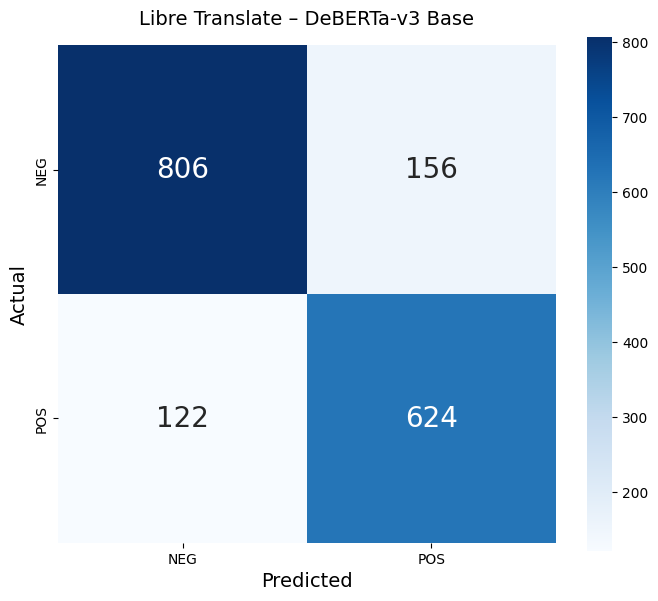


💾 CM Kaydedildi: /content/drive/MyDrive/NLP/Translation/figures/cm_libre_deberta_binary.png

📊 Dil Bazlı — DeBERTa (Libre, binary)

             Arabic  Chinese  French  Italian
Accuracy     0.8067   0.7714  0.9391   0.8223
Precision    0.8109   0.7715  0.9396   0.8264
Recall       0.8067   0.7714  0.9391   0.8223
F1-Score     0.8084   0.7714  0.9390   0.8234
Specificity  0.8416   0.7621  0.9170   0.8276


In [ ]:
cm_db = confusion_matrix(y_true_db, y_pred_db, labels=[0, 1])
TN, FP, FN, TP = cm_db.ravel()

per_class_db = pd.DataFrame({
    "Accuracy":    [np.nan]*2,
    "Precision":   precision_score(y_true_db, y_pred_db, average=None, zero_division=0),
    "Recall":      recall_score(y_true_db, y_pred_db, average=None, zero_division=0),
    "F1-Score":    f1_score(y_true_db, y_pred_db, average=None, zero_division=0),
}, index=label_names)

spec_neg = TN / (TN + FP) if (TN + FP) > 0 else 0
spec_pos = TP / (TP + FN) if (TP + FN) > 0 else 0
per_class_db["Specificity"] = [spec_neg, spec_pos]

overall_db = pd.Series({
    "Accuracy":    accuracy_score(y_true_db, y_pred_db),
    "Precision":   precision_score(y_true_db, y_pred_db, average="weighted", zero_division=0),
    "Recall":      recall_score(y_true_db, y_pred_db, average="weighted", zero_division=0),
    "F1-Score":    f1_score(y_true_db, y_pred_db, average="weighted", zero_division=0),
    "Specificity": spec_neg,
}, name="Overall (weighted)")

report_db = pd.concat([per_class_db, overall_db.to_frame().T])
print("📊 Classification Report — DeBERTa (Libre, binary)\n")
print(report_db.round(4).to_string())

save_path = os.path.join(save_dir, "cm_libre_deberta_binary.png")
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_db, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names,
            cbar=True, square=True, annot_kws={"size": 20}, ax=ax)
ax.set_xlabel("Predicted", fontsize=14)
ax.set_ylabel("Actual", fontsize=14)
ax.set_title("Libre Translate – DeBERTa-v3 Base", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"\n💾 CM Kaydedildi: {save_path}")

test_df_reset = test_df.reset_index(drop=True).copy()
test_df_reset["pred"] = y_pred_db
test_df_reset["true"] = y_true_db

lang_results_db = {}
for lang in languages:
    sub = test_df_reset[test_df_reset["language"] == lang]
    yt = sub["true"].values
    yp = sub["pred"].values
    cm_lang = confusion_matrix(yt, yp, labels=[0, 1])
    TN_l, FP_l, FN_l, TP_l = cm_lang.ravel()
    spec_l = TN_l / (TN_l + FP_l) if (TN_l + FP_l) > 0 else 0
    lang_results_db[lang_names[lang]] = {
        "Accuracy":    accuracy_score(yt, yp),
        "Precision":   precision_score(yt, yp, average="weighted", zero_division=0),
        "Recall":      recall_score(yt, yp, average="weighted", zero_division=0),
        "F1-Score":    f1_score(yt, yp, average="weighted", zero_division=0),
        "Specificity": spec_l,
    }

lang_df_db = pd.DataFrame(lang_results_db).round(4)
print("\n📊 Dil Bazlı — DeBERTa (Libre, binary)\n")
print(lang_df_db.to_string())

In [ ]:
from collections import Counter

cv_f1_scores = {
    "roberta":  0.8539,
    "bertweet": 0.8554,  # senin BERTweet CV ortalamasını koy buraya, eğer biliyorsan; aksi takdirde değiştir
    "deberta":  0.8544,
}

# Eğer BERTweet CV ortalaması bilinmiyorsa, fold sonuçlarını topla:
# cv_f1_scores["bertweet"] = np.mean([m["eval_f1_weighted"] for m in cv_results_bertweet])

preds_hard = np.stack([
    probs_rb.argmax(axis=1),
    probs_bw.argmax(axis=1),
    probs_db.argmax(axis=1),
], axis=1)

y_pred_majority = np.array([Counter(row).most_common(1)[0][0] for row in preds_hard])

avg_probs = (probs_rb + probs_bw + probs_db) / 3
y_pred_soft = avg_probs.argmax(axis=1)

w = np.array([cv_f1_scores["roberta"], cv_f1_scores["bertweet"], cv_f1_scores["deberta"]])
w = w / w.sum()
print(f"⚖️ Ağırlıklar: RoBERTa={w[0]:.4f}, BERTweet={w[1]:.4f}, DeBERTa={w[2]:.4f}")

weighted_probs = w[0] * probs_rb + w[1] * probs_bw + w[2] * probs_db
y_pred_weighted = weighted_probs.argmax(axis=1)

def eval_binary(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()
    spec = TN / (TN + FP) if (TN + FP) > 0 else 0
    return {
        "Accuracy":    accuracy_score(y_true, y_pred),
        "Precision":   precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall":      recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-Score":    f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Specificity": spec,
    }

y_true_ens = y_true_rb

results_ens = {
    "Majority Voting": eval_binary(y_true_ens, y_pred_majority),
    "Soft Voting":     eval_binary(y_true_ens, y_pred_soft),
    "Weighted Voting": eval_binary(y_true_ens, y_pred_weighted),
}

ens_df = pd.DataFrame(results_ens).T
print("\n📊 Libre Translate — Ensemble Karşılaştırması (binary)\n")
print(ens_df.round(4).to_string())

⚖️ Ağırlıklar: RoBERTa=0.3331, BERTweet=0.3337, DeBERTa=0.3333

📊 Libre Translate — Ensemble Karşılaştırması (binary)

                 Accuracy  Precision  Recall  F1-Score  Specificity
Majority Voting    0.8390     0.8391  0.8390    0.8390       0.8555
Soft Voting        0.8402     0.8404  0.8402    0.8402       0.8545
Weighted Voting    0.8402     0.8404  0.8402    0.8402       0.8545


📊 Classification Report — Majority Voting Ensemble (Libre, binary)

                    Accuracy  Precision  Recall  F1-Score  Specificity
NEG                      NaN     0.8582  0.8555    0.8568       0.8555
POS                      NaN     0.8144  0.8177    0.8161       0.8177
Overall (weighted)     0.839     0.8391  0.8390    0.8390       0.8555


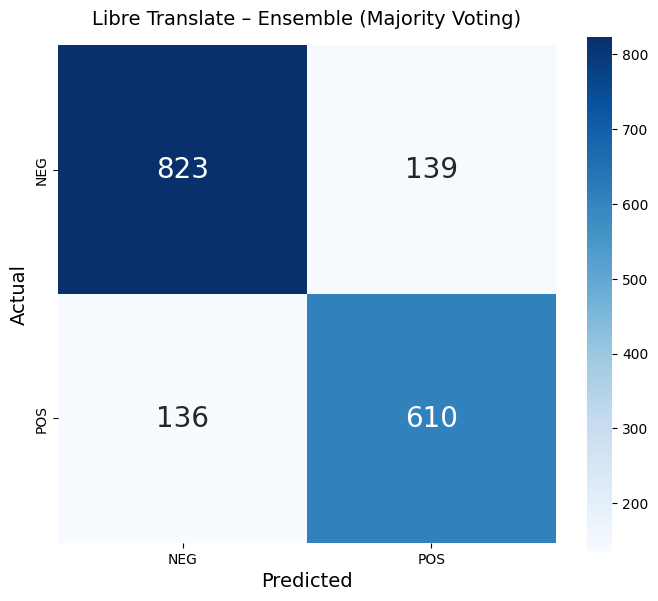


💾 CM Kaydedildi: /content/drive/MyDrive/NLP/Translation/figures/cm_libre_ensemble_majority_binary.png

📊 Dil Bazlı — Majority Voting Ensemble (Libre, binary)

             Arabic  Chinese  French  Italian
Accuracy     0.8090   0.7780  0.9307   0.8313
Precision    0.8073   0.7782  0.9312   0.8325
Recall       0.8090   0.7780  0.9307   0.8313
F1-Score     0.8081   0.7780  0.9306   0.8318
Specificity  0.8680   0.7885  0.9083   0.8522


In [ ]:
y_pred_ens = y_pred_majority

cm_ens = confusion_matrix(y_true_ens, y_pred_ens, labels=[0, 1])
TN, FP, FN, TP = cm_ens.ravel()

per_class_ens = pd.DataFrame({
    "Accuracy":    [np.nan]*2,
    "Precision":   precision_score(y_true_ens, y_pred_ens, average=None, zero_division=0),
    "Recall":      recall_score(y_true_ens, y_pred_ens, average=None, zero_division=0),
    "F1-Score":    f1_score(y_true_ens, y_pred_ens, average=None, zero_division=0),
}, index=label_names)

spec_neg = TN / (TN + FP) if (TN + FP) > 0 else 0
spec_pos = TP / (TP + FN) if (TP + FN) > 0 else 0
per_class_ens["Specificity"] = [spec_neg, spec_pos]

overall_ens = pd.Series({
    "Accuracy":    accuracy_score(y_true_ens, y_pred_ens),
    "Precision":   precision_score(y_true_ens, y_pred_ens, average="weighted", zero_division=0),
    "Recall":      recall_score(y_true_ens, y_pred_ens, average="weighted", zero_division=0),
    "F1-Score":    f1_score(y_true_ens, y_pred_ens, average="weighted", zero_division=0),
    "Specificity": spec_neg,
}, name="Overall (weighted)")

report_ens = pd.concat([per_class_ens, overall_ens.to_frame().T])
print("📊 Classification Report — Majority Voting Ensemble (Libre, binary)\n")
print(report_ens.round(4).to_string())

save_path = os.path.join(save_dir, "cm_libre_ensemble_majority_binary.png")
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_ens, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names,
            cbar=True, square=True, annot_kws={"size": 20}, ax=ax)
ax.set_xlabel("Predicted", fontsize=14)
ax.set_ylabel("Actual", fontsize=14)
ax.set_title("Libre Translate – Ensemble (Majority Voting)", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"\n💾 CM Kaydedildi: {save_path}")

test_df_reset = test_df.reset_index(drop=True).copy()
test_df_reset["pred"] = y_pred_ens
test_df_reset["true"] = y_true_ens

lang_results_ens = {}
for lang in languages:
    sub = test_df_reset[test_df_reset["language"] == lang]
    yt = sub["true"].values
    yp = sub["pred"].values
    cm_lang = confusion_matrix(yt, yp, labels=[0, 1])
    TN_l, FP_l, FN_l, TP_l = cm_lang.ravel()
    spec_l = TN_l / (TN_l + FP_l) if (TN_l + FP_l) > 0 else 0
    lang_results_ens[lang_names[lang]] = {
        "Accuracy":    accuracy_score(yt, yp),
        "Precision":   precision_score(yt, yp, average="weighted", zero_division=0),
        "Recall":      recall_score(yt, yp, average="weighted", zero_division=0),
        "F1-Score":    f1_score(yt, yp, average="weighted", zero_division=0),
        "Specificity": spec_l,
    }

lang_df_ens = pd.DataFrame(lang_results_ens).round(4)
print("\n📊 Dil Bazlı — Majority Voting Ensemble (Libre, binary)\n")
print(lang_df_ens.to_string())

In [ ]:
import os

save_root = "/content/drive/MyDrive/NLP/Translation/final_models_binary"
print(f"📂 {save_root}:\n")

for item in sorted(os.listdir(save_root)):
    path = os.path.join(save_root, item)
    if os.path.isdir(path):
        files = sorted(os.listdir(path))
        sizes = sum(os.path.getsize(os.path.join(path, f)) for f in files) / 1e6
        print(f"📁 {item}/  ({sizes:.1f} MB, {len(files)} dosya)")
    else:
        size = os.path.getsize(path) / 1e6
        print(f"📄 {item} ({size:.2f} MB)")

📂 /content/drive/MyDrive/NLP/Translation/final_models_binary:

📁 bertweet_google_binary/  (541.6 MB, 8 dosya)
📁 bertweet_libre_binary/  (541.6 MB, 8 dosya)
📁 deberta_google_binary/  (748.8 MB, 8 dosya)
📁 deberta_libre_binary/  (748.8 MB, 8 dosya)
📄 probs_bertweet_google.npy (0.01 MB)
📄 probs_bertweet_libre.npy (0.01 MB)
📄 probs_deberta_google.npy (0.01 MB)
📄 probs_deberta_libre.npy (0.01 MB)
📄 probs_roberta_google.npy (0.01 MB)
📄 probs_roberta_libre.npy (0.01 MB)
📁 roberta_google_binary/  (503.4 MB, 8 dosya)
📁 roberta_libre_binary/  (503.4 MB, 8 dosya)
